In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_csv('Air Quality.csv', encoding='cp1252')

In [3]:
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,10/03/2004,19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,10/03/2004,20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,10/03/2004,21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,10/03/2004,22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   float64
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
 15  Unnamed: 15    0 non-null      float64
 16  Unnamed: 16    0 non-null      float64
dtypes: float64(15), object(2)
memory usage: 1.2+ MB


In [6]:
df.columns

Index(['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)',
       'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)',
       'PT08.S5(O3)', 'T', 'RH', 'AH', 'Unnamed: 15', 'Unnamed: 16'],
      dtype='object')

In [22]:
#data cleaning
df.drop(columns=['Unnamed: 15', 'Unnamed: 16'], inplace=True, errors='ignore')

In [8]:
df.replace(-200, np.nan, inplace=True)
df.replace(-200.0, np.nan, inplace=True)

In [9]:
float32_cols = ['CO(GT)', 'C6H6(GT)', 'T', 'RH', 'AH']
for col in float32_cols:
    df[col] = df[col].astype('float32')

df['Date'] = df['Date'].astype('string')
df['Time'] = df['Time'].astype('string')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   string 
 1   Time           9357 non-null   string 
 2   CO(GT)         7674 non-null   float32
 3   PT08.S1(CO)    8991 non-null   float64
 4   NMHC(GT)       914 non-null    float64
 5   C6H6(GT)       8991 non-null   float32
 6   PT08.S2(NMHC)  8991 non-null   float64
 7   NOx(GT)        7718 non-null   float64
 8   PT08.S3(NOx)   8991 non-null   float64
 9   NO2(GT)        7715 non-null   float64
 10  PT08.S4(NO2)   8991 non-null   float64
 11  PT08.S5(O3)    8991 non-null   float64
 12  T              8991 non-null   float32
 13  RH             8991 non-null   float32
 14  AH             8991 non-null   float32
dtypes: float32(5), float64(8), string(2)
memory usage: 925.0 KB


In [10]:

df.drop_duplicates(inplace=True)
print('Shape after dropping duplicates:', df.shape)


Shape after dropping duplicates: (9358, 15)


In [11]:
df.isna().sum()

Date                1
Time                1
CO(GT)           1684
PT08.S1(CO)       367
NMHC(GT)         8444
C6H6(GT)          367
PT08.S2(NMHC)     367
NOx(GT)          1640
PT08.S3(NOx)      367
NO2(GT)          1643
PT08.S4(NO2)      367
PT08.S5(O3)       367
T                 367
RH                367
AH                367
dtype: int64

In [12]:
percent_missing = df.isnull().sum() * 100 / len(df)
percent_missing.sort_values(ascending=False)

NMHC(GT)         90.232956
CO(GT)           17.995298
NO2(GT)          17.557170
NOx(GT)          17.525112
PT08.S1(CO)       3.921778
C6H6(GT)          3.921778
PT08.S2(NMHC)     3.921778
PT08.S3(NOx)      3.921778
PT08.S4(NO2)      3.921778
PT08.S5(O3)       3.921778
T                 3.921778
RH                3.921778
AH                3.921778
Date              0.010686
Time              0.010686
dtype: float64

In [13]:
for col in df.columns:
    if df[col].dtype == 'object' or str(df[col].dtype) == 'string':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].mean())

In [14]:
print('Missing values after cleaning:')
print(df.isna().sum())

Missing values after cleaning:
Date             0
Time             0
CO(GT)           0
PT08.S1(CO)      0
NMHC(GT)         0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64


In [15]:
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.900002,0.7578
1,10/03/2004,19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.700001,0.7255
2,10/03/2004,20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.000000,0.7502
3,10/03/2004,21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.000000,0.7867
4,10/03/2004,22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.599998,0.7888


In [23]:
# data integration
subSet1 = df[['Date', 'Time']]


subSet2 = df[['T', 'RH', 'AH']]

subSet1.head()


,Date,Time
0,10/03/2004,18:00:00
1,10/03/2004,19:00:00
2,10/03/2004,20:00:00
3,10/03/2004,21:00:00
4,10/03/2004,22:00:00


In [19]:
subSet2.head()

,T,RH,AH
0,13.6,48.900002,0.7578
1,13.3,47.700001,0.7255
2,11.9,54.000000,0.7502
3,11.0,60.000000,0.7867
4,11.2,59.599998,0.7888


In [20]:
concatenated_df = pd.concat([subSet1, subSet2], axis=1)
concatenated_df.head()

,Date,Time,T,RH,AH
0,10/03/2004,18:00:00,13.6,48.900002,0.7578
1,10/03/2004,19:00:00,13.3,47.700001,0.7255
2,10/03/2004,20:00:00,11.9,54.000000,0.7502
3,10/03/2004,21:00:00,11.0,60.000000,0.7867
4,10/03/2004,22:00:00,11.2,59.599998,0.7888


In [21]:
pollutants = df[['CO(GT)', 'NOx(GT)', 'NO2(GT)', 'C6H6(GT)']]
env        = df[['T', 'RH', 'AH']]
merged_df  = pd.merge(pollutants, env, left_index=True, right_index=True)
merged_df.head()

,CO(GT),NOx(GT),NO2(GT),C6H6(GT),T,RH,AH
0,2.6,166.0,113.0,11.9,13.6,48.900002,0.7578
1,2.0,103.0,92.0,9.4,13.3,47.700001,0.7255
2,2.2,131.0,114.0,9.0,11.9,54.000000,0.7502
3,2.2,172.0,122.0,9.2,11.0,60.000000,0.7867
4,1.6,131.0,116.0,6.5,11.2,59.599998,0.7888


In [24]:
#data transformation
encoder = LabelEncoder()
cat_cols = ['Date', 'Time']

for col in cat_cols:
    df[col] = encoder.fit_transform(df[col].astype(str))

df[cat_cols].head()

,Date,Time
0,114,18
1,114,19
2,114,20
3,114,21
4,114,22


In [25]:
num_cols = ['CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)',
            'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)',
            'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']

scaler = MinMaxScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,114,18,0.211864,0.511845,0.120981,0.185535,0.362097,0.111036,0.310885,0.328402,0.513040,0.454822,0.333333,0.499371,0.280066
1,114,19,0.161017,0.463029,0.088832,0.146226,0.312398,0.068382,0.360864,0.266272,0.453237,0.326238,0.326882,0.484277,0.264282
2,114,20,0.177966,0.541996,0.068528,0.139937,0.303659,0.087339,0.346463,0.331361,0.451439,0.370547,0.296774,0.563522,0.276352
3,114,21,0.177966,0.523331,0.061760,0.143082,0.308575,0.115098,0.326133,0.355030,0.464478,0.426586,0.277419,0.638994,0.294190
4,114,22,0.127119,0.448672,0.037225,0.100629,0.247406,0.087339,0.373994,0.337278,0.422212,0.386186,0.281720,0.633962,0.295216


In [26]:
df[num_cols].describe()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,9358.000000,9358.000000,9358.000000,9358.000000,9358.000000,9358.000000,9358.000000,9358.000000,9358.000000,9358.000000,9358.000000,9358.000000,9358.000000
mean,0.173962,0.325078,0.179198,0.156967,0.303743,0.165807,0.217490,0.328672,0.407043,0.348352,0.434792,0.503575,0.410903
std,0.111525,0.152750,0.054033,0.114815,0.142843,0.130952,0.106620,0.129937,0.152585,0.169675,0.186176,0.213508,0.193429
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.093220,0.211055,0.179198,0.070755,0.196614,0.074475,0.145701,0.248521,0.310701,0.226325,0.298925,0.344654,0.274361
50%,0.173962,0.307251,0.179198,0.133648,0.295194,0.153690,0.210080,0.328672,0.407043,0.331017,0.434409,0.503575,0.405977
75%,0.211864,0.412060,0.179198,0.212264,0.394320,0.190928,0.270224,0.387574,0.499550,0.449175,0.559140,0.662893,0.543127
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [27]:
#error correcting
def remove_outliers(col_series):
    Q1  = col_series.quantile(0.25)
    Q3  = col_series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return col_series.clip(lower=lower, upper=upper)  # clip instead of drop to preserve rows


In [28]:
outlier_cols = ['CO(GT)', 'C6H6(GT)', 'T', 'RH', 'AH']

for col in outlier_cols:
    df[col] = remove_outliers(df[col])

print('Shape after outlier correction:', df.shape)

Shape after outlier correction: (9358, 15)


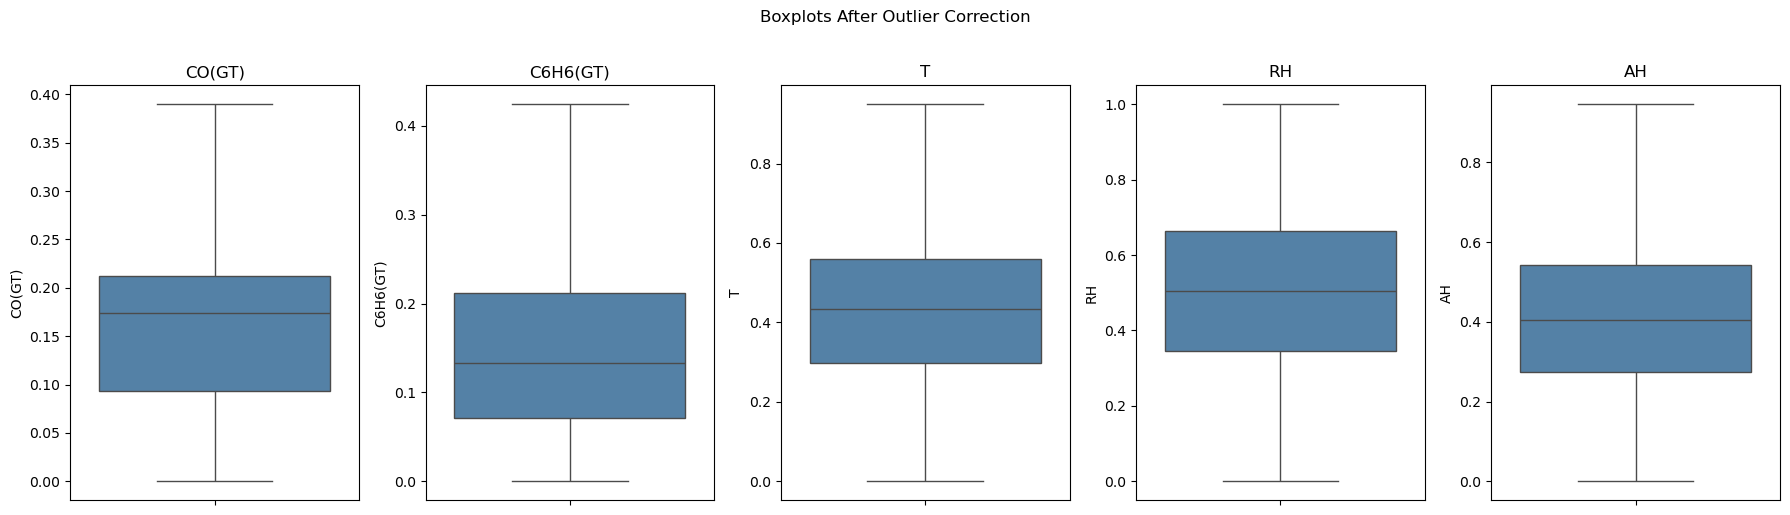

In [29]:
fig, axes = plt.subplots(1, len(outlier_cols), figsize=(18, 5))

for ax, col in zip(axes, outlier_cols):
    sns.boxplot(y=df[col], ax=ax, color='steelblue')
    ax.set_title(col)

plt.suptitle('Boxplots After Outlier Correction', y=1.02)
plt.tight_layout()
plt.show()

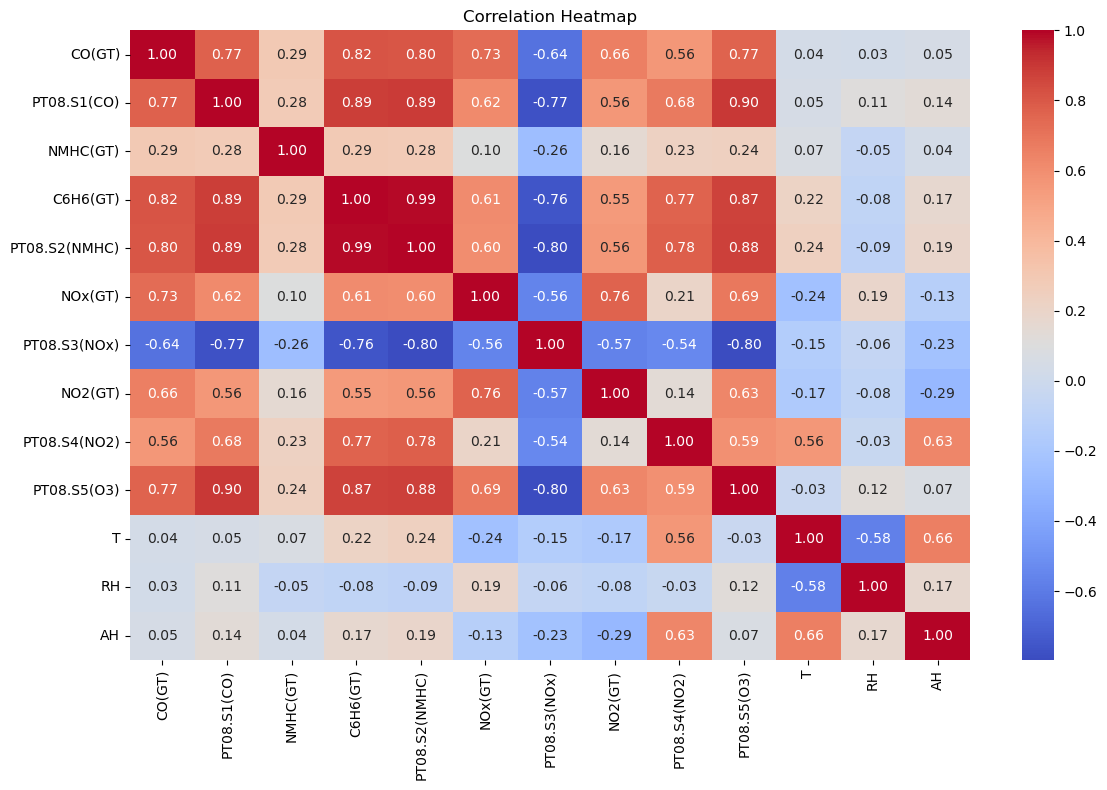

In [30]:
plt.figure(figsize=(12, 8))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [31]:
#data model building
X = df[['PT08.S1(CO)', 'C6H6(GT)', 'T', 'RH', 'AH',
         'NOx(GT)', 'NO2(GT)', 'PT08.S5(O3)']]
y = df['CO(GT)']

print('Feature matrix shape:', X.shape)
print('Target vector shape :', y.shape)

Feature matrix shape: (9358, 8)
Target vector shape : (9358,)


In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Training set :', X_train.shape)
print('Test set     :', X_test.shape)

Training set : (7486, 8)
Test set     : (1872, 8)


In [33]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [34]:
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
coef_df.sort_values('Coefficient', ascending=False)

,Feature,Coefficient
1,C6H6(GT),0.502290
5,NOx(GT),0.207547
6,NO2(GT),0.108976
0,PT08.S1(CO),0.094824
3,RH,0.013199
4,AH,0.004392
2,T,0.003468
7,PT08.S5(O3),-0.081487


In [35]:
y_pred = model.predict(X_test)

mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print(f'MSE  : {mse:.4f}')
print(f'RMSE : {rmse:.4f}')
print(f'R²   : {r2:.4f}')

MSE  : 0.0022
RMSE : 0.0464
R²   : 0.7762


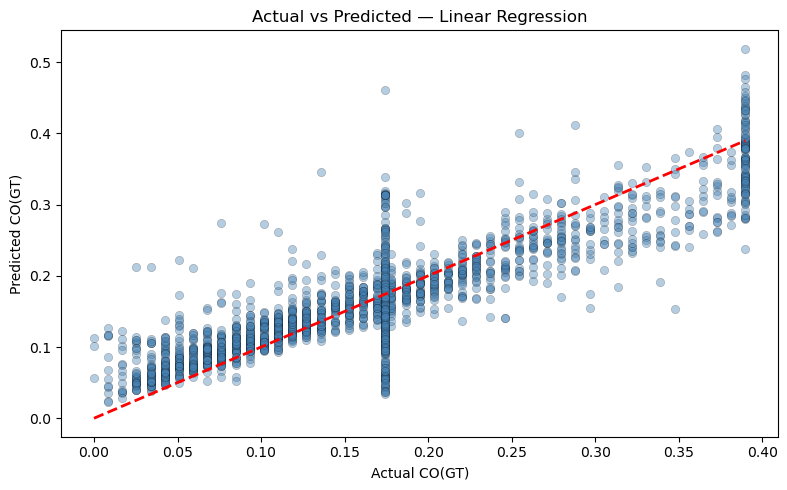

In [36]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.4, color='steelblue', edgecolors='k', linewidths=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual CO(GT)')
plt.ylabel('Predicted CO(GT)')
plt.title('Actual vs Predicted — Linear Regression')
plt.tight_layout()
plt.show()

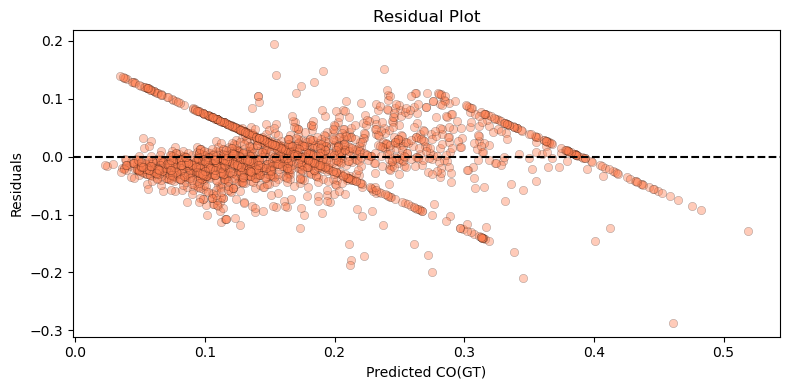

In [37]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 4))
plt.scatter(y_pred, residuals, alpha=0.4, color='coral', edgecolors='k', linewidths=0.3)
plt.axhline(0, color='black', lw=1.5, linestyle='--')
plt.xlabel('Predicted CO(GT)')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.tight_layout()
plt.show()

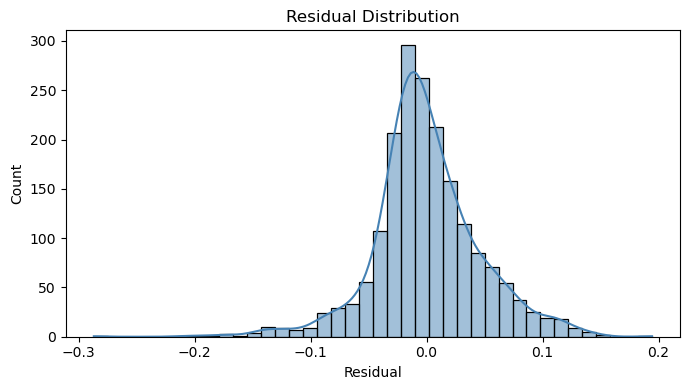

In [38]:
plt.figure(figsize=(7, 4))
sns.histplot(residuals, kde=True, color='steelblue', bins=40)
plt.xlabel('Residual')
plt.title('Residual Distribution')
plt.tight_layout()
plt.show()